# Do Bigger Discounts Mean More Engagement? (Amazon Product Data)

**Business question:** Do deeper discounts go with better ratings and more customer engagement, and which categories rely most on heavy discounting?

**Dataset:** Amazon Sales Dataset (Kaggle), 1,465 product rows. Prices are in Indian rupees.

**Tools:** Python (pandas, matplotlib), SQL (SQLite), Tableau Public.

**Note:** The data has no sales or profit column. The number of ratings is used as a rough stand-in for popularity.



## Step 1: Load and inspect the data
Check size, column types, and missing values. Prices, discounts and ratings are stored as text and need converting.

In [1]:
import pandas as pd

df = pd.read_csv('amazon.csv')

print("Rows and columns:", df.shape)
print()
print("Column names and types:")
print(df.dtypes)
print()
print("Missing values per column:")
print(df.isnull().sum())

df[['product_name', 'category', 'discounted_price', 'actual_price',
    'discount_percentage', 'rating', 'rating_count']].head()

Rows and columns: (1465, 16)

Column names and types:
product_id             object
product_name           object
category               object
discounted_price       object
actual_price           object
discount_percentage    object
rating                 object
rating_count           object
about_product          object
user_id                object
user_name              object
review_id              object
review_title           object
review_content         object
img_link               object
product_link           object
dtype: object

Missing values per column:
product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           2
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64


,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count
0,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269"
1,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994"
2,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928"
3,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363"
4,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905"


## Step 2: Clean the data
- Removed 114 duplicate products (1,465 rows down to 1,351 unique products).
- Converted price, discount and rating columns from text to numbers.
- Dropped rows with a missing rating or rating count (1,348 products remain).
- Extracted the main category and grouped discounts into four buckets: 0-20%, 21-40%, 41-60%, 61-100%.

In [2]:
# 1. Remove duplicate products
print("Rows before:", len(df))
print("Duplicate product_ids:", df['product_id'].duplicated().sum())
df = df.drop_duplicates(subset='product_id').copy()

# 2. Convert text columns into real numbers
for col in ['discounted_price', 'actual_price']:
    df[col] = (df[col].str.replace('₹', '', regex=False)
                      .str.replace(',', '', regex=False)
                      .astype(float))

df['discount_percentage'] = df['discount_percentage'].str.replace('%', '', regex=False).astype(float)
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df['rating_count'] = pd.to_numeric(df['rating_count'].str.replace(',', '', regex=False), errors='coerce')

# 3. Drop rows where rating or rating_count is missing
df = df.dropna(subset=['rating', 'rating_count'])

# 4. Pull out the main category (the first part before the first "|")
df['main_category'] = df['category'].str.split('|').str[0]

# 5. Group discounts into buckets
df['discount_bucket'] = pd.cut(df['discount_percentage'],
                               bins=[-1, 20, 40, 60, 100],
                               labels=['0-20%', '21-40%', '41-60%', '61-100%'])

# 6. Check the results
print("Rows after cleaning:", len(df))
print()
print(df[['discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count']].describe().round(1))
print()
print(df['main_category'].value_counts())
print()
print(df['discount_bucket'].value_counts().sort_index())

Rows before: 1465
Duplicate product_ids: 114
Rows after cleaning: 1348

       discounted_price  actual_price  discount_percentage  rating  \
count            1348.0        1348.0               1348.0  1348.0   
mean             3310.3        5700.5                 46.7     4.1   
std              7180.9       11229.4                 21.6     0.3   
min                39.0          39.0                  0.0     2.0   
25%               349.0         899.0                 31.0     3.9   
50%               899.0        1795.0                 49.0     4.1   
75%              2184.0        4592.5                 62.0     4.3   
max             77990.0      139900.0                 94.0     5.0   

       rating_count  
count        1348.0  
mean        17656.8  
std         42158.8  
min             2.0  
25%          1107.5  
50%          4740.0  
75%         16051.5  
max        426973.0  

main_category
Electronics              490
Home&Kitchen             447
Computers&Accessories    3

## Step 3: Ratings and engagement by discount level
Average discount is 46.7%, and 844 of 1,348 products (63%) are discounted by more than 40%.

| Discount | Products | Avg rating | Median rating count |
|---|---|---|---|
| 0-20% | 175 | 4.17 | 6,736 |
| 21-40% | 329 | 4.13 | 7,241 |
| 41-60% | 469 | 4.07 | 3,025 |
| 61-100% | 375 | 4.05 | 4,149 |

Ratings dip slightly as discounts grow, and engagement does not rise with deeper discounts. Median is used because rating counts are very skewed. Correlations are weak (discount vs rating -0.15, discount vs rating count -0.13).

                 products  avg_rating  median_rating_count
discount_bucket                                           
0-20%                 175        4.17               6736.0
21-40%                329        4.13               7241.0
41-60%                469        4.07               3025.0
61-100%               375        4.05               4149.0

                     discount_percentage  rating  rating_count
discount_percentage                 1.00   -0.15         -0.13
rating                             -0.15    1.00          0.19
rating_count                       -0.13    0.19          1.00


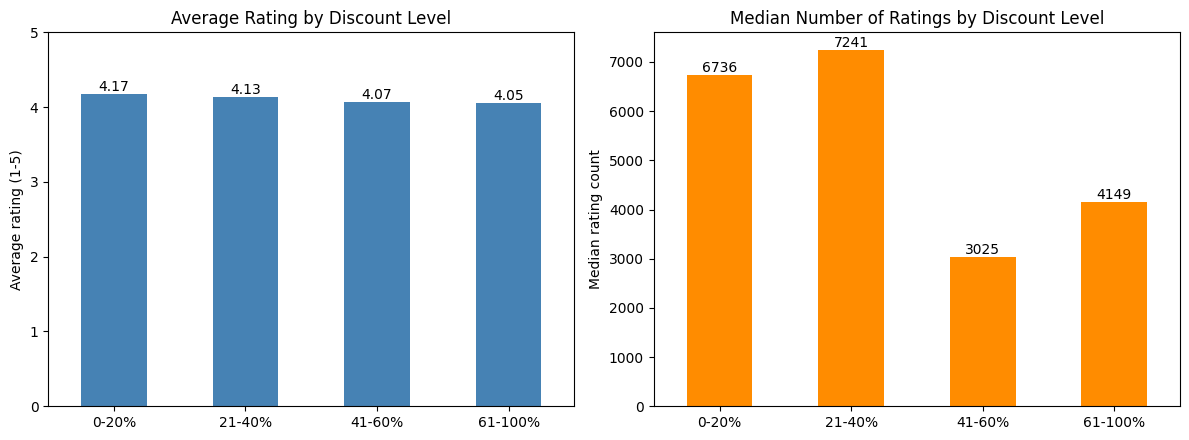

In [3]:
import matplotlib.pyplot as plt

# 1. Average rating and typical rating_count for each discount bucket
bucket = df.groupby('discount_bucket', observed=True).agg(
    products=('product_id', 'count'),
    avg_rating=('rating', 'mean'),
    median_rating_count=('rating_count', 'median')
).round(2)
print(bucket)
print()

# 2. Correlation between discount, rating and rating_count
print(df[['discount_percentage', 'rating', 'rating_count']].corr(method='spearman').round(2))

# 3. Charts
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

bucket['avg_rating'].plot(kind='bar', ax=ax[0], color='steelblue')
ax[0].set_title('Average Rating by Discount Level')
ax[0].set_ylabel('Average rating (1-5)')
ax[0].set_xlabel('')
ax[0].set_ylim(0, 5)
ax[0].bar_label(ax[0].containers[0])
ax[0].tick_params(axis='x', rotation=0)

bucket['median_rating_count'].plot(kind='bar', ax=ax[1], color='darkorange')
ax[1].set_title('Median Number of Ratings by Discount Level')
ax[1].set_ylabel('Median rating count')
ax[1].set_xlabel('')
ax[1].bar_label(ax[1].containers[0])
ax[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### Which categories rely most on heavy discounting?
Only the three large categories are compared (others have 31 products or fewer).

**Result:** Computers&Accessories has the highest average discount (53.1%, 40.8% of products over 60% off), then Electronics (49.9%, 35.7%), then Home&Kitchen (40.2%, 10.5%).

                       products  avg_discount  pct_over_60_discount  \
main_category                                                         
Computers&Accessories       373          53.1                  40.8   
Electronics                 490          49.9                  35.7   
Home&Kitchen                447          40.2                  10.5   

                       avg_rating  median_rating_count  
main_category                                           
Computers&Accessories         4.2               7317.0  
Electronics                   4.1               9129.5  
Home&Kitchen                  4.0               2311.0  


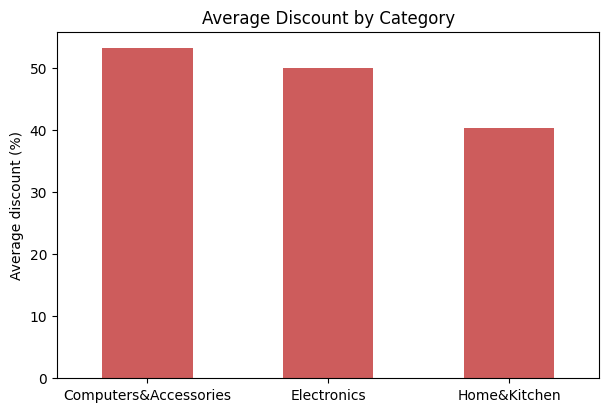

In [4]:
main_cats = ['Electronics', 'Home&Kitchen', 'Computers&Accessories']
cat = df[df['main_category'].isin(main_cats)]

cat_summary = cat.groupby('main_category').agg(
    products=('product_id', 'count'),
    avg_discount=('discount_percentage', 'mean'),
    pct_over_60_discount=('discount_percentage', lambda s: (s > 60).mean() * 100),
    avg_rating=('rating', 'mean'),
    median_rating_count=('rating_count', 'median')
).round(1).sort_values('avg_discount', ascending=False)

print(cat_summary)

cat_summary['avg_discount'].plot(kind='bar', color='indianred', figsize=(7, 4.5))
plt.title('Average Discount by Category')
plt.ylabel('Average discount (%)')
plt.xlabel('')
plt.xticks(rotation=0)
plt.show()

## Step 4: Check within each category
Repeat the comparison inside each category, so category mix does not distort the result.

**Result:** In all three categories, products discounted 61-100% have lower median rating counts than those discounted 21-40% (Computers 2,886 vs 11,827; Electronics 9,340 vs 16,134; Home&Kitchen 578 vs 3,916). The pattern is not perfectly smooth, and ratings fall with discount in Electronics and Home&Kitchen but not in Computers.

In [5]:
main_cats = ['Electronics', 'Home&Kitchen', 'Computers&Accessories']
cat = df[df['main_category'].isin(main_cats)]

print("Number of products:")
print(cat.pivot_table(index='main_category', columns='discount_bucket',
                      values='product_id', aggfunc='count', observed=True))
print()
print("Median rating count:")
print(cat.pivot_table(index='main_category', columns='discount_bucket',
                      values='rating_count', aggfunc='median', observed=True).round(0))
print()
print("Average rating:")
print(cat.pivot_table(index='main_category', columns='discount_bucket',
                      values='rating', aggfunc='mean', observed=True).round(2))

Number of products:
discount_bucket        0-20%  21-40%  41-60%  61-100%
main_category                                        
Computers&Accessories     28      67     126      152
Electronics               50     118     147      175
Home&Kitchen              71     140     189       47

Median rating count:
discount_bucket          0-20%   21-40%  41-60%  61-100%
main_category                                           
Computers&Accessories   7276.0  11827.0  7335.0   2886.0
Electronics            17612.0  16134.0  3664.0   9340.0
Home&Kitchen            4570.0   3916.0  1456.0    578.0

Average rating:
discount_bucket        0-20%  21-40%  41-60%  61-100%
main_category                                        
Computers&Accessories   4.03    4.21    4.21     4.11
Electronics             4.18    4.12    4.05     4.04
Home&Kitchen            4.16    4.09    3.99     3.93


## Step 5: Validate with SQL
Copy the cleaned table into SQLite and re-answer the key questions.

**Query 1:** Ratings and engagement by discount bucket. Averages are used here because SQLite has no median. The 61-100% bucket has the highest average rating count (20,378), unlike the median result, because a few very popular products pull the average up.

In [6]:
import sqlite3

sql_df = df[['product_id', 'product_name', 'main_category', 'discounted_price',
             'actual_price', 'discount_percentage', 'rating', 'rating_count']].copy()
sql_df['discount_bucket'] = df['discount_bucket'].astype(str)

conn = sqlite3.connect(':memory:')
sql_df.to_sql('products', conn, index=False)

def sql(query):
    return pd.read_sql_query(query, conn)

# Query 1: ratings and engagement by discount bucket
sql("""
SELECT discount_bucket,
       COUNT(*) AS products,
       ROUND(AVG(rating), 2) AS avg_rating,
       ROUND(AVG(rating_count), 0) AS avg_rating_count
FROM products
GROUP BY discount_bucket
ORDER BY discount_bucket
""")

,discount_bucket,products,avg_rating,avg_rating_count
0,0-20%,175,4.17,14561.0
1,21-40%,329,4.13,19644.0
2,41-60%,469,4.07,15242.0
3,61-100%,375,4.05,20378.0


**Query 2:** Categories by average discount, using CASE WHEN and HAVING. Matches the Python results.

In [7]:
# Query 2: which categories rely on heavy discounting?
sql("""
SELECT main_category,
       COUNT(*) AS products,
       ROUND(AVG(discount_percentage), 1) AS avg_discount,
       ROUND(AVG(CASE WHEN discount_percentage > 60 THEN 1.0 ELSE 0 END) * 100, 1) AS pct_over_60
FROM products
GROUP BY main_category
HAVING COUNT(*) >= 100
ORDER BY avg_discount DESC
""")

,main_category,products,avg_discount,pct_over_60
0,Computers&Accessories,373,53.1,40.8
1,Electronics,490,49.9,35.7
2,Home&Kitchen,447,40.2,10.5


**Query 3:** Most-rated product in each category, using a window function (ROW_NUMBER with PARTITION BY).

**Result:** The top product in each category is heavily discounted (56-69% off): a USB drive, an HDMI cable and a kitchen chopper, each with 250,000+ ratings.

In [8]:
# Query 3: the most-rated product in each category (window function)
sql("""
SELECT main_category,
       SUBSTR(product_name, 1, 40) AS product,
       discount_percentage,
       rating,
       rating_count
FROM (
    SELECT *,
           ROW_NUMBER() OVER (PARTITION BY main_category ORDER BY rating_count DESC) AS rn
    FROM products
    WHERE main_category IN ('Electronics', 'Home&Kitchen', 'Computers&Accessories')
)
WHERE rn = 1
""")

,main_category,product,discount_percentage,rating,rating_count
0,Computers&Accessories,SanDisk Cruzer Blade 32GB USB Flash Driv,56.0,4.3,253105.0
1,Electronics,AmazonBasics Flexible Premium HDMI Cable,69.0,4.4,426973.0
2,Home&Kitchen,Pigeon Polypropylene Mini Handy and Comp,60.0,4.1,270563.0


## Step 6: Export clean data for the Tableau dashboard

In [9]:
export = df[['product_id', 'main_category', 'discount_percentage', 'discount_bucket',
             'discounted_price', 'actual_price', 'rating', 'rating_count']].copy()
export['discount_bucket'] = export['discount_bucket'].astype(str)
export.to_csv('amazon_clean_for_dashboard.csv', index=False)
print(export.shape)

from google.colab import files
files.download('amazon_clean_for_dashboard.csv')

(1348, 8)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Findings and limitations

## Key findings
1. Heavy discounting is the norm: average discount is 46.7%, and 63% of products are over 40% off.
2. Deeper discounts did not go with higher engagement for the typical product. In all three main categories, products at 61-100% off had lower median rating counts than those at 21-40% off.
3. Ratings dip slightly with deeper discounts (4.17 to 4.05), but not in every category.
4. Computers&Accessories relies most on heavy discounting, and Home&Kitchen the least.
5. Exception: a few cheap, everyday items are heavily discounted and still collect hundreds of thousands of ratings.

## Limitations
- No sales or profit data. Rating count is only a rough proxy for popularity, and older products collect more ratings.
- This shows association, not cause. Weaker products may need bigger discounts to sell at all.
- Only three categories were large enough to compare.
- Duplicate products were removed, and rows with missing ratings were dropped.